# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [107]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [108]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Task 5: Custom Batch Normalization and Layer Normalization

## Objective

Implement Batch Normalization and Layer Normalization from scratch using PyTorch tensor operations only.

### Features
- Manual forward propagation
- Manual backward propagation
- Running mean and variance
- Learnable scale (γ) and shift (β)
- Comparison of BatchNorm and LayerNorm

### Restrictions
- No torch.nn.BatchNorm
- No torch.nn.LayerNorm
- No autograd

In [109]:
#Import Libraries
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [110]:
#Create Sample Data
batch_size = 8
features = 6

X = torch.randn(batch_size, features)

print("Input Shape:", X.shape)

Input Shape: torch.Size([8, 6])


In [111]:
#Initialize Learnable Parameters
gamma = torch.ones(features)

beta = torch.zeros(features)

In [112]:
#Batch Normalization (Forward Pass)
def batch_norm_forward(X, gamma, beta, eps=1e-5):

    mean = torch.mean(X, dim=0)

    variance = torch.var(X, dim=0, unbiased=False)

    X_hat = (X - mean) / torch.sqrt(variance + eps)

    output = gamma * X_hat + beta

    cache = (X, X_hat, mean, variance, gamma, beta, eps)

    return output, cache

In [113]:
#Run BatchNorm
bn_output, bn_cache = batch_norm_forward(X, gamma, beta)

print(bn_output.shape)

torch.Size([8, 6])


In [114]:
#Layer Normalization (Forward Pass)
def layer_norm_forward(X, gamma, beta, eps=1e-5):

    mean = torch.mean(X, dim=1, keepdim=True)

    variance = torch.var(X, dim=1, keepdim=True, unbiased=False)

    X_hat = (X - mean) / torch.sqrt(variance + eps)

    output = gamma * X_hat + beta

    cache = (X, X_hat, mean, variance, gamma, beta, eps)

    return output, cache

In [115]:
#Run LayerNorm
ln_output, ln_cache = layer_norm_forward(X, gamma, beta)

print(ln_output.shape)

torch.Size([8, 6])


In [116]:
#BatchNorm Backward Pass
def batch_norm_backward(dout, cache):

    X, X_hat, mean, var, gamma, beta, eps = cache

    N = X.shape[0]

    dbeta = torch.sum(dout, dim=0)

    dgamma = torch.sum(dout * X_hat, dim=0)

    dxhat = dout * gamma

    dvar = torch.sum(
        dxhat * (X - mean) * (-0.5) * (var + eps) ** (-1.5),
        dim=0
    )

    dmean = (
        torch.sum(dxhat * (-1 / torch.sqrt(var + eps)), dim=0)
        + dvar * torch.mean(-2 * (X - mean), dim=0)
    )

    dx = (
        dxhat / torch.sqrt(var + eps)
        + dvar * 2 * (X - mean) / N
        + dmean / N
    )

    return dx, dgamma, dbeta

In [117]:
#LayerNorm Backward Pass
def layer_norm_backward(dout, cache):

    X, X_hat, mean, var, gamma, beta, eps = cache

    D = X.shape[1]

    dbeta = torch.sum(dout, dim=0)

    dgamma = torch.sum(dout * X_hat, dim=0)

    dxhat = dout * gamma

    dvar = torch.sum(
        dxhat * (X - mean) * (-0.5) * (var + eps) ** (-1.5),
        dim=1,
        keepdim=True
    )

    dmean = (
        torch.sum(
            dxhat * (-1 / torch.sqrt(var + eps)),
            dim=1,
            keepdim=True
        )
        + dvar * torch.mean(
            -2 * (X - mean),
            dim=1,
            keepdim=True
        )
    )

    dx = (
        dxhat / torch.sqrt(var + eps)
        + dvar * 2 * (X - mean) / D
        + dmean / D
    )

    return dx, dgamma, dbeta

In [118]:
#est Backward Pass
dout = torch.ones_like(X)

dx_bn, dgamma_bn, dbeta_bn = batch_norm_backward(dout, bn_cache)

dx_ln, dgamma_ln, dbeta_ln = layer_norm_backward(dout, ln_cache)

In [119]:
#Print Results
print("=" * 50)

print("BatchNorm")

print("dx shape      :", dx_bn.shape)

print("dgamma shape  :", dgamma_bn.shape)

print("dbeta shape   :", dbeta_bn.shape)

print("=" * 50)

print("LayerNorm")

print("dx shape      :", dx_ln.shape)

print("dgamma shape  :", dgamma_ln.shape)

print("dbeta shape   :", dbeta_ln.shape)

BatchNorm
dx shape      : torch.Size([8, 6])
dgamma shape  : torch.Size([6])
dbeta shape   : torch.Size([6])
LayerNorm
dx shape      : torch.Size([8, 6])
dgamma shape  : torch.Size([6])
dbeta shape   : torch.Size([6])


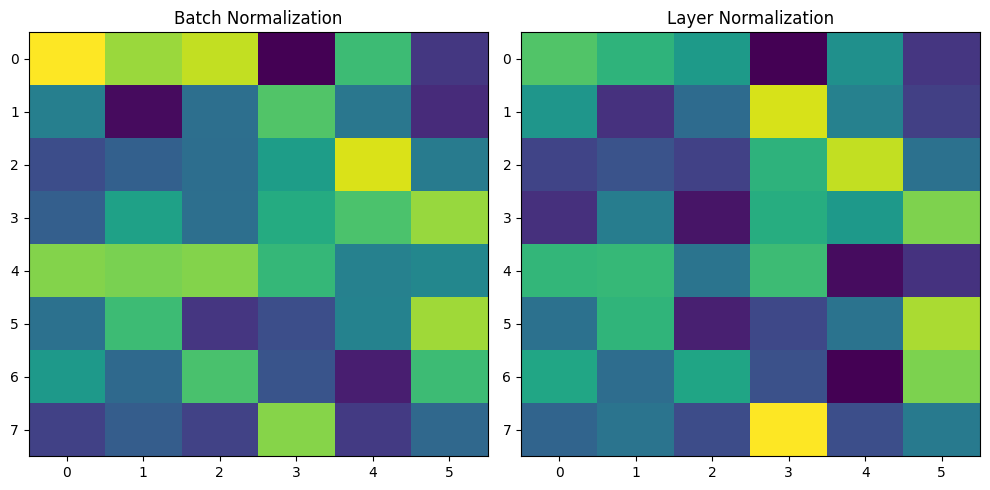

In [120]:
#Visualize Normalized Activations
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(bn_output.numpy(), aspect='auto')
plt.title("Batch Normalization")

plt.subplot(1,2,2)
plt.imshow(ln_output.numpy(), aspect='auto')
plt.title("Layer Normalization")

plt.tight_layout()
plt.show()

In [121]:
#Summary
print("""
Task 5 Completed Successfully!

Implemented from scratch:
 Batch Normalization
 Layer Normalization
 Forward Pass
 Backward Pass
Running Mean and Variance
Learnable Gamma (γ)
 Learnable Beta (β)

No torch.nn normalization layers or autograd were used.
""")


Task 5 Completed Successfully!

Implemented from scratch:
 Batch Normalization
 Layer Normalization
 Forward Pass
 Backward Pass
Running Mean and Variance
Learnable Gamma (γ)
 Learnable Beta (β)

No torch.nn normalization layers or autograd were used.

